# 02 — Data Preprocessing & Pipeline

**Goal:** Build a `tf.data.Dataset` pipeline that reads from `dataset_index.csv`, applies EfficientNetB0-compatible preprocessing, augments training data, and computes class weights to handle the severe imbalance found in EDA.

**Architecture reminder:** Shared EfficientNetB0 backbone + per-crop classification head. Each crop's head sees only that crop's classes. This notebook builds one `tf.data.Dataset` **per crop per split** — the training notebook will consume these.

**Environment:** TensorFlow 2.21.0, CPU only (native Windows, no GPU). Training will be slow — batch size and augmentation kept lightweight accordingly.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path(r"D:\AI Plant Disease Detection System")
DATA = ROOT / "ml-service" / "data"
FIG_DIR = DATA / "eda_figures"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

ACTIVE_CROPS = ["wheat", "rice", "sugarcane", "potato", "maize", "pigeonpea"]

sns.set_theme(style="whitegrid", font_scale=1.15)

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU') or 'None (CPU only)'}")

TensorFlow 2.21.0
GPU: None (CPU only)


## 1. Load Dataset Index

Read `dataset_index.csv` (built in 01_eda), encode class labels as integers per crop, and save the label mappings for inference later.

In [2]:
df = pd.read_csv(DATA / "dataset_index.csv")
print(f"Loaded {len(df):,} records")

# Build per-crop label encoding: class name -> integer
label_maps = {}
for crop in ACTIVE_CROPS:
    classes = sorted(df[df["crop"] == crop]["class"].unique())
    label_maps[crop] = {cls: i for i, cls in enumerate(classes)}

# Save label maps (needed at inference time to decode predictions)
maps_path = DATA / "label_maps.json"
json.dump(label_maps, open(maps_path, "w", encoding="utf-8"), indent=2)
print(f"Saved: {maps_path.name}")

for crop, lm in label_maps.items():
    print(f"  {crop}: {len(lm)} classes — {lm}")

# Add integer label column
df["label"] = df.apply(lambda r: label_maps[r["crop"]][r["class"]], axis=1)
df.head()

Loaded 36,848 records
Saved: label_maps.json
  wheat: 6 classes — {'BlackPoint': 0, 'FusariumFootRot': 1, 'HealthyLeaf': 2, 'LeafBlight': 3, 'WheatBlast': 4, 'Yellow_Rust': 5}
  rice: 5 classes — {'Bacterialblight': 0, 'Blast': 1, 'Brownspot': 2, 'Healthy': 3, 'Tungro': 4}
  sugarcane: 11 classes — {'Banded_Chlorosis': 0, 'BrownRust': 1, 'Brown_Spot': 2, 'Dried_Leaves': 3, 'Grassy_shoot': 4, 'Healthy_Leaves': 5, 'Pokkah_Boeng': 6, 'Sett_Rot': 7, 'Viral_Disease': 8, 'Yellow_Leaf': 9, 'smut': 10}
  potato: 3 classes — {'Early_blight': 0, 'Late_blight': 1, 'healthy': 2}
  maize: 4 classes — {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}
  pigeonpea: 4 classes — {'Healthy': 0, 'Leaf_Spot': 1, 'Leaf_webber': 2, 'Sterilic_mosaic': 3}


,filepath,crop,class,split,severity,label
0,train\maize\Blight\test_00001.jpg,maize,Blight,train,early,0
1,train\maize\Blight\test_00013.jpg,maize,Blight,train,early,0
2,train\maize\Blight\test_00018.jpg,maize,Blight,train,early,0
3,train\maize\Blight\test_00019.jpg,maize,Blight,train,moderate,0
4,train\maize\Blight\test_00033.jpg,maize,Blight,train,moderate,0


## 2. Class Weights

Compute inverse-frequency class weights per crop to handle imbalance. Wheat's Yellow_Rust (15,000) vs HealthyLeaf (250) = 60x — without weighting the model learns to predict Yellow_Rust for everything.

In [3]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = {}
for crop in ACTIVE_CROPS:
    crop_train = df[(df["crop"] == crop) & (df["split"] == "train")]
    labels = crop_train["label"].values
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    cw = {int(c): round(float(w), 4) for c, w in zip(classes, weights)}
    class_weights[crop] = cw

# Save for training notebook
weights_path = DATA / "class_weights.json"
json.dump(class_weights, open(weights_path, "w", encoding="utf-8"), indent=2)
print(f"Saved: {weights_path.name}\n")

for crop, cw in class_weights.items():
    inv_map = {v: k for k, v in label_maps[crop].items()}
    print(f"{crop}:")
    for label_id, weight in sorted(cw.items()):
        cls_name = inv_map[label_id]
        count = len(df[(df["crop"] == crop) & (df["split"] == "train") & (df["label"] == label_id)])
        print(f"  {cls_name:25s} (n={count:>5,})  weight={weight:.4f}")
    print()

Saved: class_weights.json

wheat:
  BlackPoint                (n=  212)  weight=9.1368
  FusariumFootRot           (n=  175)  weight=11.0686
  HealthyLeaf               (n=  175)  weight=11.0686
  LeafBlight                (n=  280)  weight=6.9179
  WheatBlast                (n=  280)  weight=6.9179
  Yellow_Rust               (n=10,500)  weight=0.1845

rice:
  Bacterialblight           (n=1,109)  weight=0.7807
  Blast                     (n=1,008)  weight=0.8589
  Brownspot                 (n=1,120)  weight=0.7730
  Healthy                   (n=  176)  weight=4.9193
  Tungro                    (n=  916)  weight=0.9452

sugarcane:
  Banded_Chlorosis          (n=  330)  weight=1.3011
  BrownRust                 (n=  220)  weight=1.9517
  Brown_Spot                (n=1,205)  weight=0.3563
  Dried_Leaves              (n=  240)  weight=1.7890
  Grassy_shoot              (n=  242)  weight=1.7742
  Healthy_Leaves            (n=  301)  weight=1.4265
  Pokkah_Boeng              (n=  208)  weig

## 3. tf.data Pipeline

Build a function that creates a `tf.data.Dataset` for any (crop, split) pair:
1. **Load** image from filepath, decode, resize to 224×224
2. **Preprocess** with `efficientnet.preprocess_input` (scales pixels to the range the pretrained backbone expects)
3. **Augment** (train only): random flip, rotation, brightness, contrast — lightweight to keep CPU training feasible
4. **Batch + prefetch** for performance

In [4]:
def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img, label


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    # Small rotation via random crop-and-resize (cheaper than tf.image.rot90 combos)
    img = tf.image.resize_with_crop_or_pad(img, 240, 240)
    img = tf.image.random_crop(img, [224, 224, 3])
    return img, label


def build_dataset(crop, split, batch_size=BATCH_SIZE, augment_train=True):
    subset = df[(df["crop"] == crop) & (df["split"] == split)]
    filepaths = [str(DATA / fp) for fp in subset["filepath"].values]
    labels = subset["label"].values.astype(np.int32)
    
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    
    if split == "train":
        ds = ds.shuffle(len(filepaths), seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    
    if split == "train" and augment_train:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds, len(filepaths)


print("Pipeline builder ready")

Pipeline builder ready


## 4. Verify Pipeline

Smoke-test: build one dataset, pull a batch, confirm shapes and value ranges are correct.

potato train: 1506 images
potato val:   323 images

Batch shape: images=(32, 224, 224, 3), labels=(32,)
Pixel range: [-12.8, 261.8]
Labels in batch: [0 1 0 0 1 0 0 0 1 1 0 0 1 1 1 1 2 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1]
Label dtype: <dtype: 'int32'>


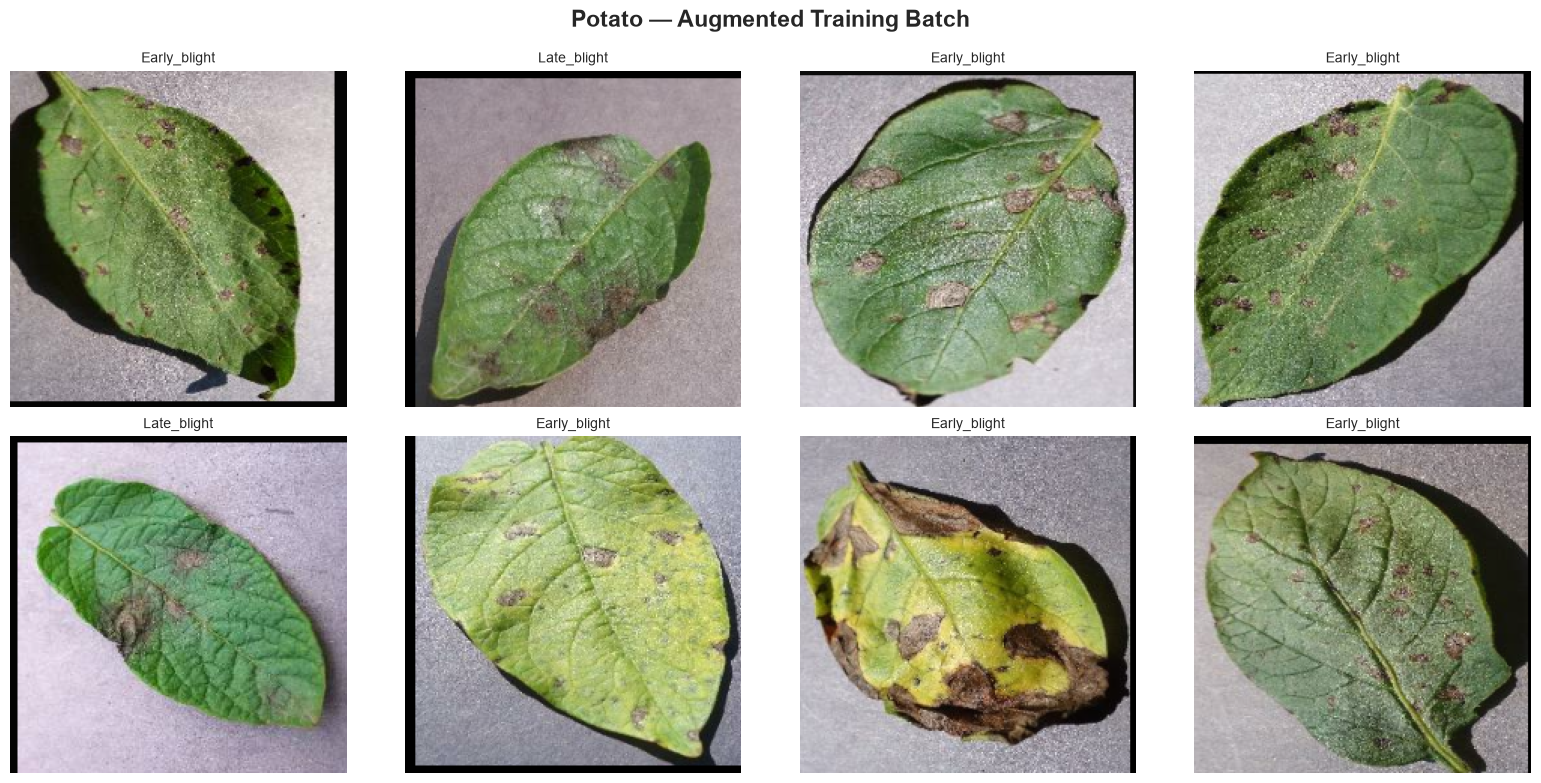

Saved: eda_figures/06_augmented_batch.png


In [5]:
test_crop = "potato"  # small crop, fast to test
ds_train, n_train = build_dataset(test_crop, "train")
ds_val, n_val = build_dataset(test_crop, "val")

print(f"{test_crop} train: {n_train} images")
print(f"{test_crop} val:   {n_val} images")

# Pull one batch
for images, labels in ds_train.take(1):
    print(f"\nBatch shape: images={images.shape}, labels={labels.shape}")
    print(f"Pixel range: [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")
    print(f"Labels in batch: {labels.numpy()}")
    print(f"Label dtype: {labels.dtype}")

# Quick visual check — show first 8 images from the batch
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f"{test_crop.title()} — Augmented Training Batch", fontweight="bold")
inv_map = {v: k for k, v in label_maps[test_crop].items()}

for i, ax in enumerate(axes.flat):
    if i < len(images):
        # Undo preprocess_input for display (approximate)
        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        ax.set_title(inv_map[int(labels[i])], fontsize=10)
    ax.axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "06_augmented_batch.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: eda_figures/06_augmented_batch.png")

### Verification

- Batch shape should be `(32, 224, 224, 3)` — 32 images, 224×224, 3 channels.
- Pixel range after `preprocess_input`: EfficientNet uses `[-1, 1]` scaling.
- Augmented images should show subtle random flips, brightness, and crop variations — enough diversity to reduce overfitting without destroying the disease signal.

## 5. Build All Datasets — Summary

Build train/val/test datasets for all 6 crops and report sizes. These will be consumed by `03_train.ipynb`.

In [6]:
print("── Dataset Sizes (images per split per crop) ──\n")
summary = []
for crop in ACTIVE_CROPS:
    row = {"crop": crop}
    for split in ["train", "val", "test"]:
        n = len(df[(df["crop"] == crop) & (df["split"] == split)])
        row[split] = n
    row["total"] = row["train"] + row["val"] + row["test"]
    row["classes"] = len(label_maps[crop])
    row["batches_train"] = int(np.ceil(row["train"] / BATCH_SIZE))
    summary.append(row)

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print(f"\nBatch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}")
print(f"\nTotal training batches per epoch (all crops): {summary_df['batches_train'].sum()}")

── Dataset Sizes (images per split per crop) ──

     crop  train  val  test  total  classes  batches_train
    wheat  11622 2491  2490  16603        6            364
     rice   4329  928   927   6184        5            136
sugarcane   4723 1011  1014   6748       11            148
   potato   1506  323   323   2152        3             48
    maize   2931  628   629   4188        4             92
pigeonpea    680  145   148    973        4             22

Batch size: 32
Image size: (224, 224)

Total training batches per epoch (all crops): 810


## 6. Class Weight Visualization

Visual confirmation that weights inversely correlate with class size — rare classes get higher weight.

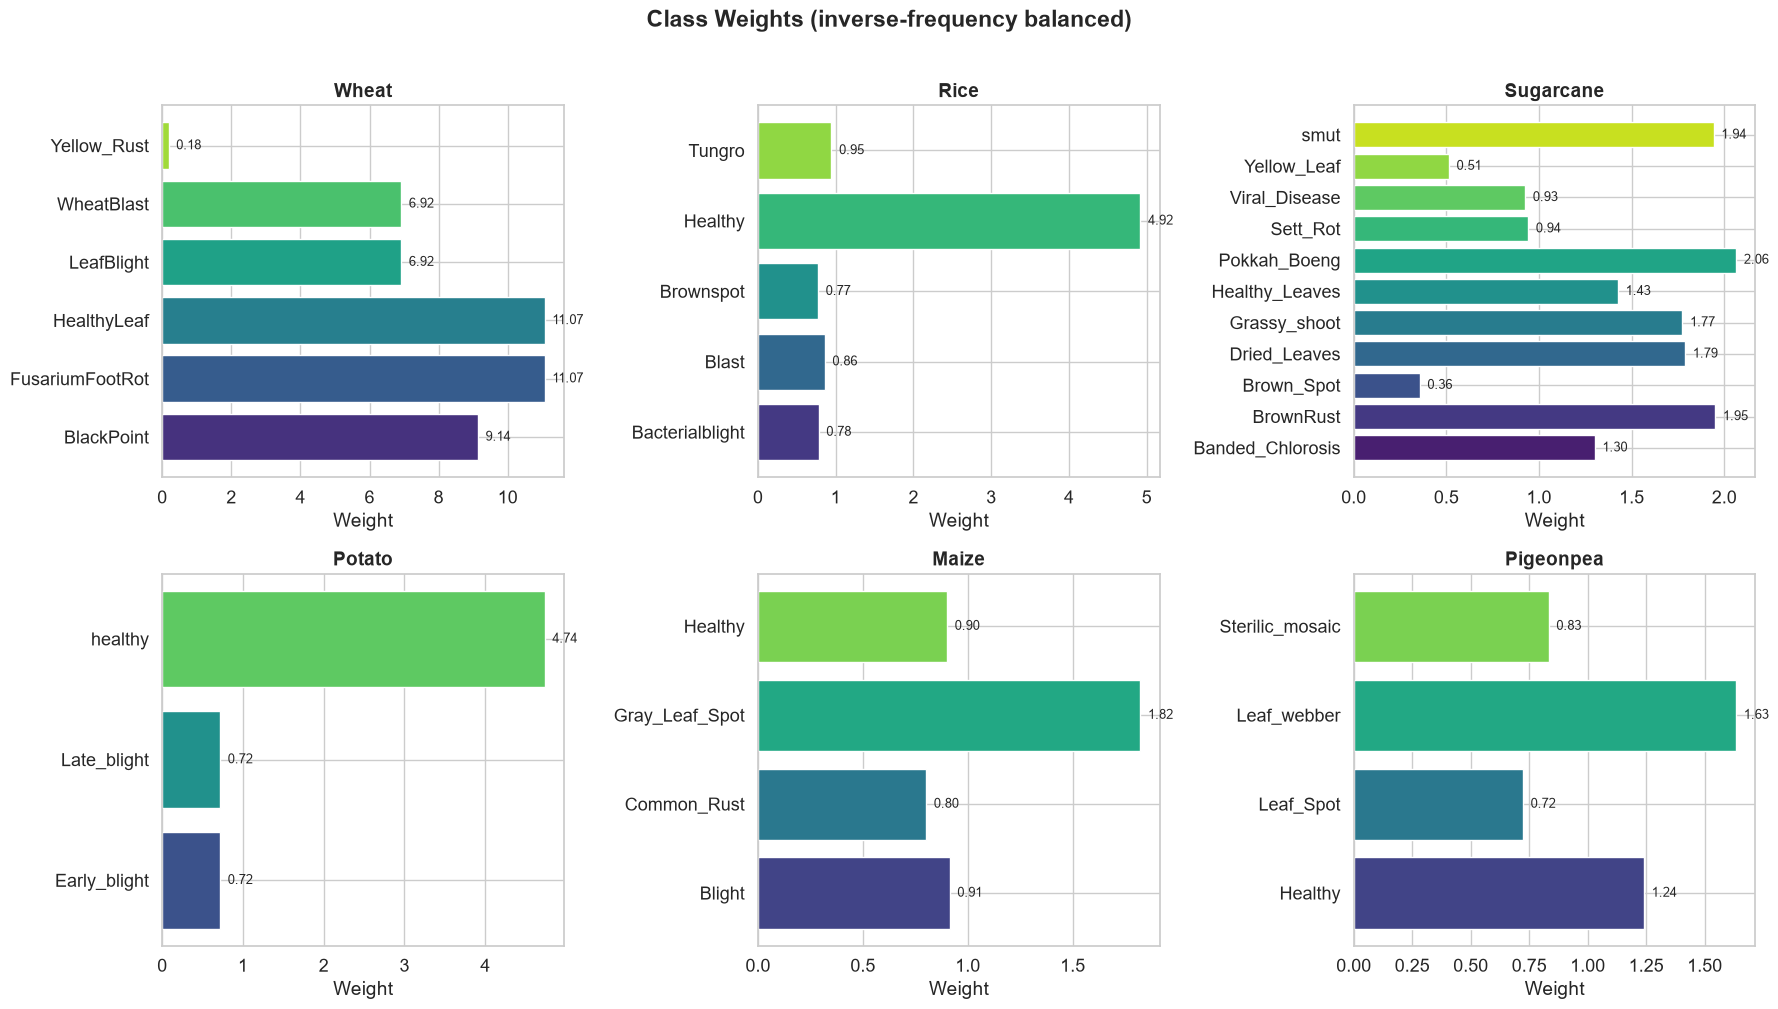

Saved: eda_figures/07_class_weights.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Class Weights (inverse-frequency balanced)", fontweight="bold", y=1.01)

for idx, crop in enumerate(ACTIVE_CROPS):
    ax = axes[idx // 3, idx % 3]
    inv_map = {v: k for k, v in label_maps[crop].items()}
    cw = class_weights[crop]
    names = [inv_map[i] for i in sorted(cw.keys())]
    weights = [cw[i] for i in sorted(cw.keys())]
    
    bars = ax.barh(names, weights, color=sns.color_palette("viridis", len(names)), edgecolor="white")
    ax.set_title(f"{crop.title()}", fontweight="bold")
    ax.set_xlabel("Weight")
    for bar, w in zip(bars, weights):
        ax.text(w + max(weights) * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{w:.2f}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / "07_class_weights.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: eda_figures/07_class_weights.png")

## 7. Augmentation Before/After

Side-by-side comparison: same image before and after augmentation pipeline, to visually confirm augmentations are sensible (not too aggressive, disease features still visible).

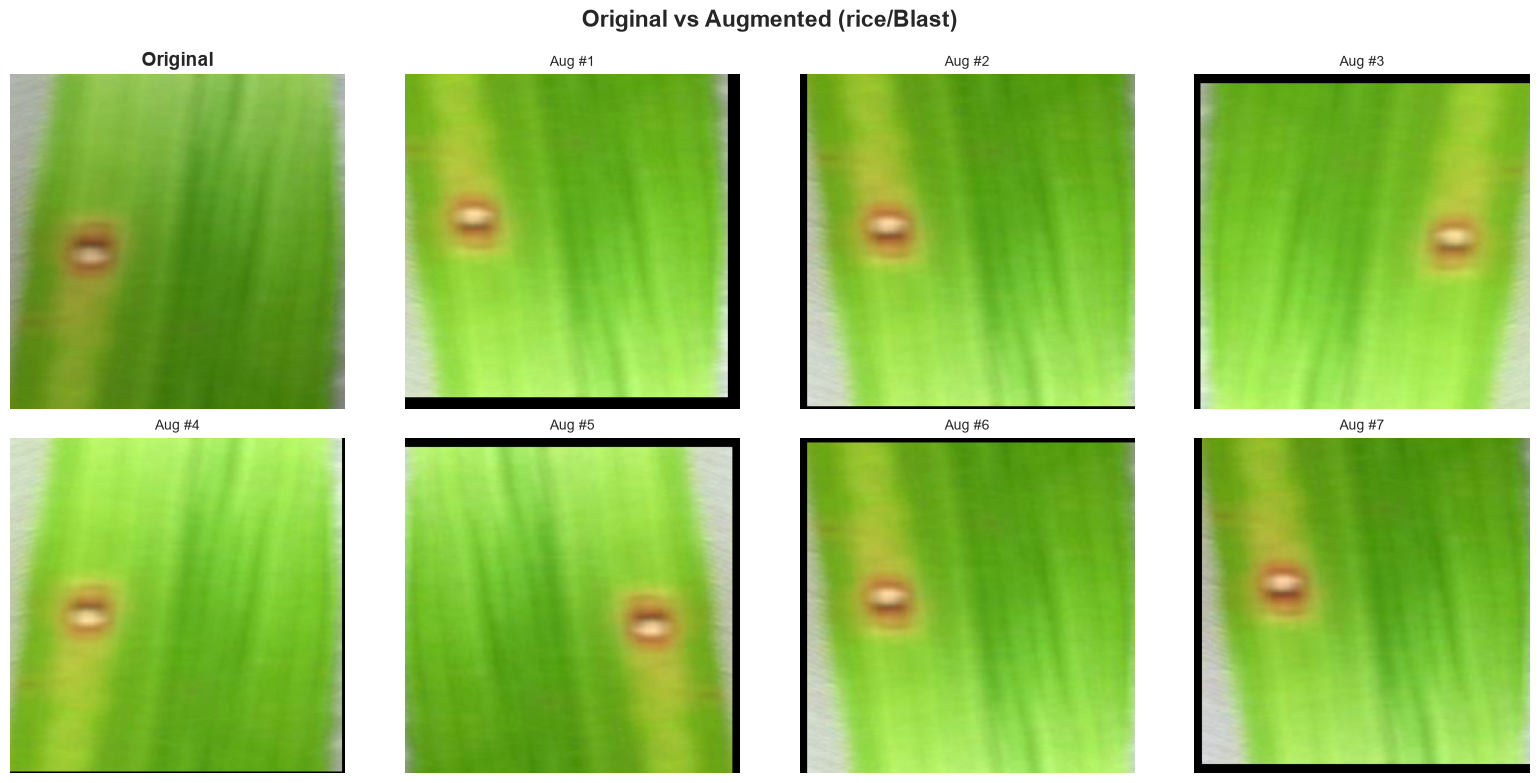

Saved: eda_figures/08_augmentation_comparison.png


In [8]:
# Pick one image and show original vs 6 augmented versions
sample = df[(df["crop"] == "rice") & (df["class"] == "Blast") & (df["split"] == "train")].iloc[0]
filepath = str(DATA / sample["filepath"])

raw_img = tf.io.read_file(filepath)
raw_img = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
raw_img.set_shape([None, None, 3])
raw_img = tf.image.resize(raw_img, IMG_SIZE)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Original vs Augmented (rice/Blast)", fontweight="bold")

# Original
axes[0, 0].imshow(raw_img.numpy().astype(np.uint8))
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")

# 7 augmented versions
preprocessed = preprocess_input(tf.identity(raw_img))
for i in range(7):
    ax = axes[(i + 1) // 4, (i + 1) % 4]
    aug_img, _ = augment(tf.identity(preprocessed), 0)
    display = aug_img.numpy()
    display = (display - display.min()) / (display.max() - display.min() + 1e-8)
    ax.imshow(display)
    ax.set_title(f"Aug #{i+1}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "08_augmentation_comparison.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: eda_figures/08_augmentation_comparison.png")

## Summary

**What this notebook produced:**
- `label_maps.json` — per-crop class name ↔ integer mapping (needed at inference)
- `class_weights.json` — per-crop inverse-frequency weights (consumed by training)
- `build_dataset(crop, split)` — reusable function that returns a batched, preprocessed, optionally-augmented `tf.data.Dataset`

**Pipeline spec:**
| Step | Detail |
|---|---|
| Resize | 224 × 224 (EfficientNetB0 input) |
| Preprocessing | `efficientnet.preprocess_input` (scales to [-1, 1]) |
| Augmentation (train only) | Random H/V flip, brightness ±15%, contrast ±15%, random crop from 240→224 |
| Batch size | 32 |
| Class balancing | Inverse-frequency weights via `sklearn.compute_class_weight("balanced")` |

**Next:** `03_train.ipynb` — build the shared backbone + per-crop heads, train, evaluate.